## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

Vamos a comparar una red convolucional hecha "a mano" (ad-hoc) frente a usar un modelo ya entrenado (transfer learning) y frente a "descongelar" parte de ese modelo para seguir entrenándolo (fine tuning). Usamos el dataset de paisajes **Intel Image Classification** (Kaggle), con 6 clases: `buildings`, `forest`, `glacier`, `mountain`, `sea`, `street`.

Todo el notebook está explicado paso a paso, en un lenguaje sencillo, como si fuera la primera vez que trabajamos con transfer learning.

**Nota sobre los tiempos de entrenamiento**: el dataset completo tiene unas 14.000 imágenes de train y 3.000 de test. Para que el notebook se pueda ejecutar en un tiempo razonable en un ordenador normal (sin GPU), trabajamos con una **muestra representativa** (300 imágenes por clase en train, 80 por clase en test). Si tienes un ordenador potente o GPU, puedes subir `N_TRAIN_POR_CLASE` y `N_TEST_POR_CLASE` para usar más datos.

**Nota importante sobre el transfer learning**: la primera vez que se carga MobileNetV2 con `weights="imagenet"`, Keras descarga automáticamente los pesos preentrenados desde internet (son unos pocos MB). Necesitas conexión a internet la primera vez que ejecutes esas celdas en tu ordenador; luego quedan guardados en caché local.


### Ejercicio 0

Importamos los paquetes que vamos a necesitar. Además de lo habitual (numpy, cv2, matplotlib...), aquí aparecen dos cosas nuevas:

- `MobileNetV2`: una red convolucional ya entrenada por Google con millones de imágenes (el dataset ImageNet). La vamos a reutilizar en vez de entrenar una red desde cero.
- `preprocess_input`: cada red preentrenada espera que las imágenes estén preparadas (normalizadas) de una forma concreta; esta función hace exactamente eso para MobileNetV2.


In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

np.random.seed(42)
tf.random.set_seed(42)


### Objetivo del ejercicio y dataset

Comparamos una red convolucional hecha ad-hoc frente a un modelo preentrenado (transfer learning) y frente a ese mismo modelo con fine-tuning, usando el dataset de paisajes.

Los datos, tal y como los descargas de Kaggle, quedan organizados así:

```
seg_train/seg_train/<clase>/*.jpg
seg_test/seg_test/<clase>/*.jpg
```

donde `<clase>` es una de: `buildings`, `forest`, `glacier`, `mountain`, `sea`, `street`.


## 1. Preparar los datos

Igual que en la práctica anterior de CNN, escribimos una función para cargar las imágenes. La diferencia es que aquí la clase no está en el nombre del archivo, sino en el **nombre de la carpeta** que contiene cada imagen.

Vamos a cargar las imágenes dos veces, a dos resoluciones distintas:

- **32x32**, para la CNN ad-hoc (igual que en la práctica anterior, así es más rápida de entrenar desde cero).
- **96x96**, para MobileNetV2 (los modelos preentrenados necesitan un tamaño mínimo de imagen para funcionar bien).

Para no leer los archivos del disco dos veces, cargamos primero a 96x96 y luego generamos la versión de 32x32 reduciendo esas mismas imágenes con `cv2.resize`.


In [2]:
TRAIN_PATH = "data/seg_train/seg_train"
TEST_PATH = "data/seg_test/seg_test"

IMG_SIZE_ADHOC = 32
IMG_SIZE_TL = 96

# usamos una muestra representativa para que el notebook se entrene en un tiempo razonable
N_TRAIN_POR_CLASE = 300
N_TEST_POR_CLASE = 80


def cargar_imagenes(directorio, n_por_clase, size):
    """
    Recorre las carpetas de 'directorio' (una por clase), carga hasta n_por_clase
    imagenes de cada una, las redimensiona a size x size y guarda su etiqueta
    (el indice de la clase segun el nombre de carpeta, en orden alfabetico).
    """
    X, y = [], []
    clases = sorted(os.listdir(directorio))

    for indice_clase, nombre_clase in enumerate(clases):
        carpeta = os.path.join(directorio, nombre_clase)
        archivos = sorted(os.listdir(carpeta))[:n_por_clase]

        for archivo in archivos:
            imagen = cv2.imread(os.path.join(carpeta, archivo))
            imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
            imagen = cv2.resize(imagen, (size, size))

            X.append(imagen)
            y.append(indice_clase)

    return np.array(X), np.array(y), clases


# cargamos a resolucion "grande" (96x96) para el transfer learning
X_train_96, y_train, CLASES = cargar_imagenes(TRAIN_PATH, N_TRAIN_POR_CLASE, IMG_SIZE_TL)
X_test_96, y_test, _ = cargar_imagenes(TEST_PATH, N_TEST_POR_CLASE, IMG_SIZE_TL)

# generamos la version pequenya (32x32) reduciendo las imagenes que ya tenemos cargadas,
# para no tener que volver a leer todo del disco
X_train_32 = np.array([cv2.resize(img, (IMG_SIZE_ADHOC, IMG_SIZE_ADHOC)) for img in X_train_96])
X_test_32 = np.array([cv2.resize(img, (IMG_SIZE_ADHOC, IMG_SIZE_ADHOC)) for img in X_test_96])

print("Clases:", CLASES)
print("X_train_96:", X_train_96.shape, " X_train_32:", X_train_32.shape)
print("X_test_96:", X_test_96.shape, " X_test_32:", X_test_32.shape)


FileNotFoundError: [WinError 3] El sistema no puede encontrar la ruta especificada: 'data/seg_train/seg_train'

Normalizamos las imágenes de dos formas distintas, porque cada modelo lo necesita distinto:

- Para la CNN ad-hoc: dividimos entre 255 para dejar los valores entre 0 y 1 (igual que en la práctica anterior).
- Para MobileNetV2: usamos su propia función `preprocess_input`, que aplica la normalización concreta con la que se entrenó ese modelo en ImageNet (no es simplemente dividir entre 255).


In [ ]:
X_train_32_norm = X_train_32.astype("float32") / 255.0
X_test_32_norm = X_test_32.astype("float32") / 255.0

X_train_96_tl = preprocess_input(X_train_96.astype("float32"))
X_test_96_tl = preprocess_input(X_test_96.astype("float32"))


## Visualización del dataset (mini EDA)

Vemos cuántas imágenes tenemos de cada clase y unos cuantos ejemplos.


buildings    300
forest       300
glacier      300
mountain     300
sea          300
street       300
Name: count, dtype: int64


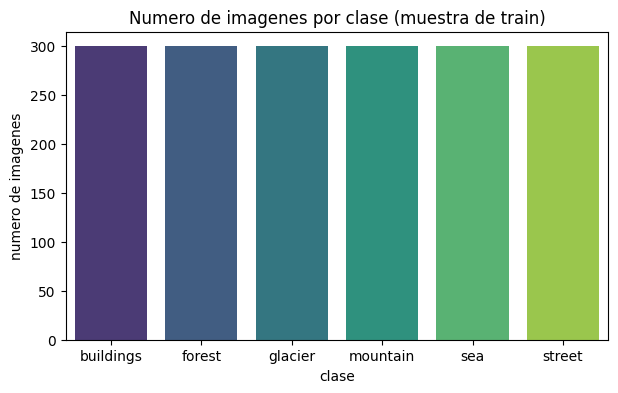

In [ ]:
import pandas as pd

conteo = pd.Series(y_train).map(dict(enumerate(CLASES))).value_counts()
print(conteo)

plt.figure(figsize=(7, 4))
sns.barplot(x=conteo.index, y=conteo.values, hue=conteo.index, palette="viridis", legend=False)
plt.title("Numero de imagenes por clase (muestra de train)")
plt.ylabel("numero de imagenes")
plt.xlabel("clase")
plt.show()


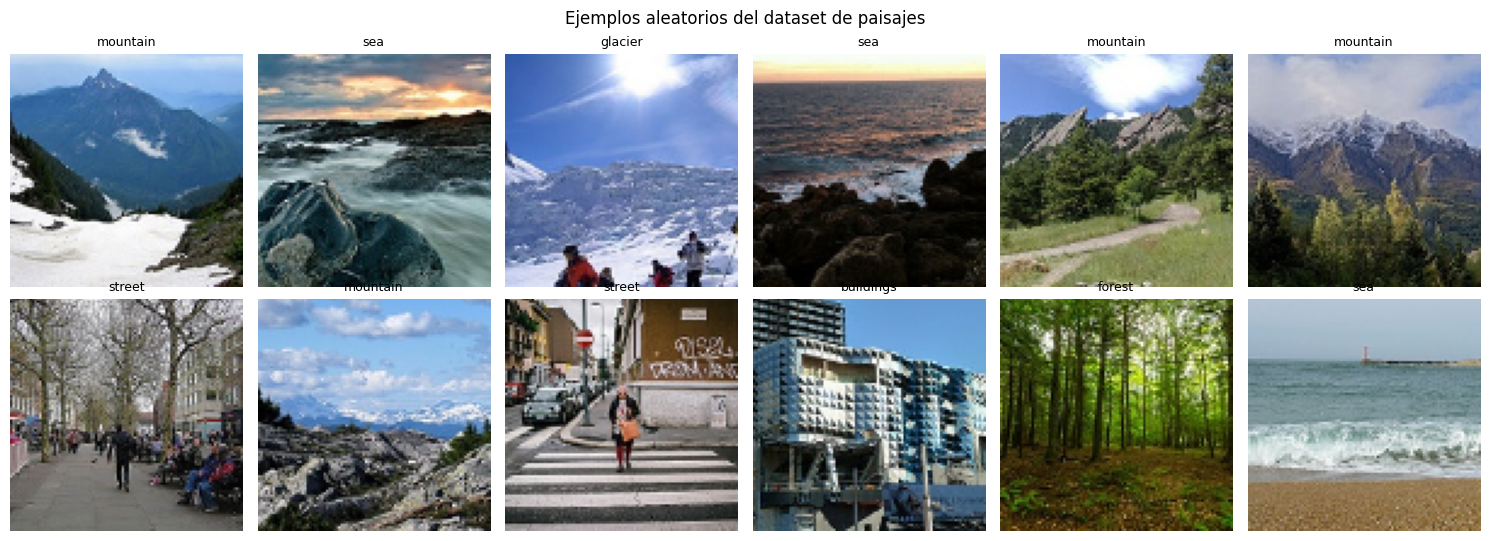

In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for ax in axes.flatten():
    idx = np.random.randint(0, len(X_train_96))
    ax.imshow(X_train_96[idx])
    ax.set_title(CLASES[y_train[idx]], fontsize=9)
    ax.axis("off")

plt.suptitle("Ejemplos aleatorios del dataset de paisajes")
plt.tight_layout()
plt.show()


## 2. CNN ad-hoc de referencia

Antes de usar un modelo preentrenado, construimos una CNN sencilla desde cero (como en la práctica anterior de la unidad 1), para tener con qué comparar más adelante. Dos bloques Conv2D + MaxPooling2D, y como aquí tenemos **6 clases** (no 2 como en perros/gatos), la salida es una capa `Dense` con 6 neuronas y activación `softmax` (nos da una probabilidad para cada una de las 6 clases).


In [ ]:
model_adhoc = keras.Sequential([
    layers.Input(shape=(IMG_SIZE_ADHOC, IMG_SIZE_ADHOC, 3)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(CLASES), activation="softmax"),
])

model_adhoc.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model_adhoc.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281,990 (1.08 MB)

 Trainable params: 281,990 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

Usamos `sparse_categorical_crossentropy` en vez de `binary_crossentropy` porque ahora tenemos más de 2 clases, y las etiquetas son números enteros (0 a 5) en vez de "one-hot". Entrenamos con EarlyStopping, igual que en la práctica anterior.

In [ ]:
early_stopping_adhoc = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history_adhoc = model_adhoc.fit(
    X_train_32_norm, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping_adhoc],
    verbose=2,
)


Epoch 1/20


45/45 - 2s - 54ms/step - accuracy: 0.3674 - loss: 1.5198 - val_accuracy: 0.0000e+00 - val_loss: 3.4951


Epoch 2/20


45/45 - 1s - 21ms/step - accuracy: 0.5333 - loss: 1.1760 - val_accuracy: 0.0083 - val_loss: 4.1463


Epoch 3/20


45/45 - 1s - 28ms/step - accuracy: 0.5840 - loss: 1.0638 - val_accuracy: 0.0167 - val_loss: 4.3914


Epoch 4/20


45/45 - 1s - 28ms/step - accuracy: 0.5951 - loss: 1.0188 - val_accuracy: 0.0222 - val_loss: 4.7269


              precision    recall  f1-score   support

   buildings       0.39      0.68      0.49        80
      forest       0.44      0.89      0.59        80
     glacier       0.48      0.72      0.57        80
    mountain       0.72      0.51      0.60        80
         sea       0.00      0.00      0.00        80
      street       0.00      0.00      0.00        80

    accuracy                           0.47       480
   macro avg       0.34      0.47      0.38       480
weighted avg       0.34      0.47      0.38       480



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


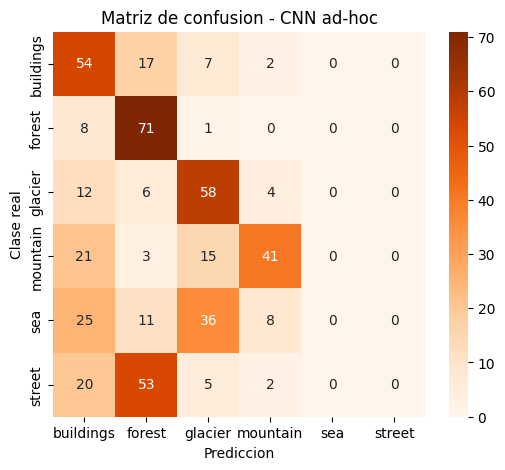

Accuracy CNN ad-hoc: 0.467


In [ ]:
y_pred_adhoc = model_adhoc.predict(X_test_32_norm, verbose=0).argmax(axis=1)

print(classification_report(y_test, y_pred_adhoc, target_names=CLASES))

matriz_adhoc = confusion_matrix(y_test, y_pred_adhoc)
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_adhoc, annot=True, fmt="d", cmap="Oranges", xticklabels=CLASES, yticklabels=CLASES)
plt.xlabel("Prediccion")
plt.ylabel("Clase real")
plt.title("Matriz de confusion - CNN ad-hoc")
plt.show()

accuracy_adhoc = (y_pred_adhoc == y_test).mean()
print(f"Accuracy CNN ad-hoc: {accuracy_adhoc:.3f}")


## 3. Transfer Learning con MobileNetV2

Ahora, en vez de aprender los filtros de la red desde cero, reutilizamos **MobileNetV2**, ya entrenado con millones de imágenes (dataset ImageNet). La idea del transfer learning:

1. Cargamos MobileNetV2 **sin** su "cabeza" de clasificación (`include_top=False`), es decir, nos quedamos solo con la parte que sabe extraer características de una imagen (bordes, texturas, formas, objetos...).
2. **Congelamos** todos sus pesos (`base_model.trainable = False`): no queremos que se "olviden" de lo aprendido, solo vamos a entrenar la parte nueva que añadamos.
3. Añadimos nuestra propia "cabeza" de clasificación encima: como mucho 2 capas densas ocultas y una de salida (aquí usamos 1 capa oculta de 128 neuronas + la capa de salida de 6 neuronas).

`GlobalAveragePooling2D` resume cada mapa de características en un solo número (su media), reduciendo mucho el número de parámetros comparado con un `Flatten` directo.


In [ ]:
try:
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3),
        include_top=False,
        weights="imagenet",
    )
except Exception as e:
    # si no hay conexion a internet para descargar los pesos de imagenet, avisamos
    # y seguimos con pesos aleatorios solo para que el notebook no se rompa
    print("Aviso: no se pudieron descargar los pesos de imagenet:", e)
    base_model = MobileNetV2(input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3), include_top=False, weights=None)

base_model.trainable = False  # congelamos el modelo preentrenado

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
salida = layers.Dense(len(CLASES), activation="softmax")(x)

model_tl = keras.Model(inputs=base_model.input, outputs=salida)

model_tl.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print(f"Capas totales: {len(model_tl.layers)} | Capas entrenables: {sum(l.trainable for l in model_tl.layers)}")


Aviso: no se pudieron descargar los pesos de imagenet: URL fetch failure on https://storage.googleapis.com/tensorflow/keras-applications/mobilenet_v2/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_96_no_top.h5: 403 -- Forbidden


Capas totales: 158 | Capas entrenables: 4


In [ ]:
early_stopping_tl = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history_tl = model_tl.fit(
    X_train_96_tl, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_tl],
    verbose=2,
)


Epoch 1/15


45/45 - 13s - 294ms/step - accuracy: 0.2153 - loss: 1.7711 - val_accuracy: 0.0000e+00 - val_loss: 2.0039


Epoch 2/15


45/45 - 7s - 164ms/step - accuracy: 0.2007 - loss: 1.7214 - val_accuracy: 0.0000e+00 - val_loss: 2.3696


Epoch 3/15


45/45 - 12s - 266ms/step - accuracy: 0.2097 - loss: 1.6749 - val_accuracy: 0.0000e+00 - val_loss: 2.8064


Epoch 4/15


45/45 - 10s - 227ms/step - accuracy: 0.2083 - loss: 1.6484 - val_accuracy: 0.0000e+00 - val_loss: 3.2095


              precision    recall  f1-score   support

   buildings       0.17      1.00      0.29        80
      forest       0.00      0.00      0.00        80
     glacier       0.00      0.00      0.00        80
    mountain       0.00      0.00      0.00        80
         sea       0.00      0.00      0.00        80
      street       0.00      0.00      0.00        80

    accuracy                           0.17       480
   macro avg       0.03      0.17      0.05       480
weighted avg       0.03      0.17      0.05       480



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


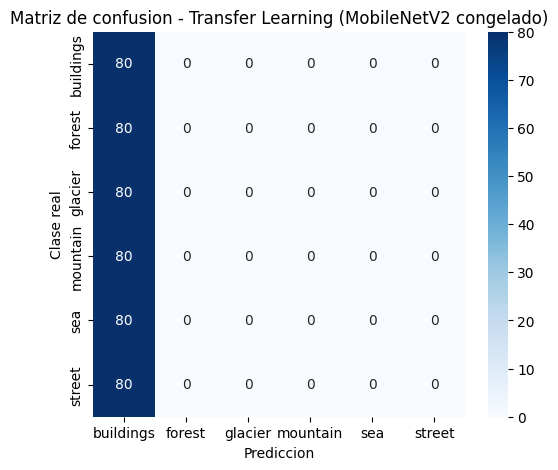

Accuracy Transfer Learning: 0.167


In [ ]:
y_pred_tl = model_tl.predict(X_test_96_tl, verbose=0).argmax(axis=1)

print(classification_report(y_test, y_pred_tl, target_names=CLASES))

matriz_tl = confusion_matrix(y_test, y_pred_tl)
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_tl, annot=True, fmt="d", cmap="Blues", xticklabels=CLASES, yticklabels=CLASES)
plt.xlabel("Prediccion")
plt.ylabel("Clase real")
plt.title("Matriz de confusion - Transfer Learning (MobileNetV2 congelado)")
plt.show()

accuracy_tl = (y_pred_tl == y_test).mean()
print(f"Accuracy Transfer Learning: {accuracy_tl:.3f}")


## 4. Fine-Tuning

En el transfer learning anterior, MobileNetV2 estaba completamente congelado: solo aprendía nuestra "cabeza" nueva. En el **fine-tuning** vamos un paso más allá: "descongelamos" las últimas capas del modelo preentrenado para que también se ajusten (afinen) a nuestro problema concreto de paisajes, mientras dejamos congeladas las primeras capas (que suelen detectar patrones muy genéricos, como bordes y texturas, útiles para cualquier imagen).

Es importante usar un **learning rate muy bajo** en esta fase: como el modelo ya está bastante entrenado, si usamos un learning rate normal podríamos "romper" de golpe lo que ya sabía.


In [ ]:
# descongelamos solo las ultimas 30 capas de MobileNetV2, dejamos el resto tal cual
base_model.trainable = True
for capa in base_model.layers[:-30]:
    capa.trainable = False

# recompilamos el modelo (obligatorio en Keras despues de cambiar que capas son entrenables)
# con un learning rate mucho mas bajo que el que usa Adam por defecto
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print(f"Capas entrenables tras descongelar: {sum(l.trainable for l in model_tl.layers)} de {len(model_tl.layers)}")


Capas entrenables tras descongelar: 34 de 158


In [ ]:
early_stopping_ft = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history_ft = model_tl.fit(
    X_train_96_tl, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping_ft],
    verbose=2,
)


Epoch 1/10


45/45 - 18s - 398ms/step - accuracy: 0.2590 - loss: 1.6594 - val_accuracy: 0.0000e+00 - val_loss: 1.9997


Epoch 2/10


45/45 - 18s - 406ms/step - accuracy: 0.2993 - loss: 1.5789 - val_accuracy: 0.0000e+00 - val_loss: 1.9926


Epoch 3/10


...

45/45 - 10s - 231ms/step - accuracy: 0.3694 - loss: 1.4650 - val_accuracy: 0.0000e+00 - val_loss: 1.9891


Epoch 7/10


45/45 - 10s - 230ms/step - accuracy: 0.3847 - loss: 1.4478 - val_accuracy: 0.0000e+00 - val_loss: 2.0013


Epoch 8/10


45/45 - 12s - 270ms/step - accuracy: 0.4056 - loss: 1.4092 - val_accuracy: 0.0000e+00 - val_loss: 2.0105


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

   buildings       0.17      1.00      0.29        80
      forest       0.00      0.00      0.00        80
     glacier       0.00      0.00      0.00        80
    mountain       0.00      0.00      0.00        80
         sea       0.00      0.00      0.00        80
      street       0.00      0.00      0.00        80

    accuracy                           0.17       480
   macro avg       0.03      0.17      0.05       480
weighted avg       0.03      0.17      0.05       480



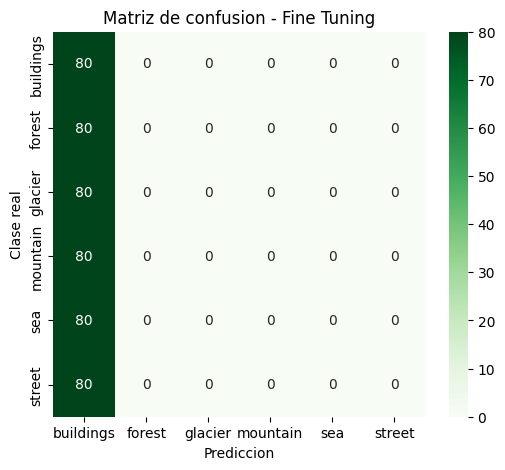

Accuracy Fine Tuning: 0.167


In [ ]:
y_pred_ft = model_tl.predict(X_test_96_tl, verbose=0).argmax(axis=1)

print(classification_report(y_test, y_pred_ft, target_names=CLASES))

matriz_ft = confusion_matrix(y_test, y_pred_ft)
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_ft, annot=True, fmt="d", cmap="Greens", xticklabels=CLASES, yticklabels=CLASES)
plt.xlabel("Prediccion")
plt.ylabel("Clase real")
plt.title("Matriz de confusion - Fine Tuning")
plt.show()

accuracy_ft = (y_pred_ft == y_test).mean()
print(f"Accuracy Fine Tuning: {accuracy_ft:.3f}")


## 5. Comparación de los tres modelos

Ponemos en un solo gráfico el accuracy de test de los tres enfoques: la CNN ad-hoc, el transfer learning (con MobileNetV2 congelado) y el fine-tuning.


              modelo  accuracy
0         CNN ad-hoc  0.466667
1  Transfer Learning  0.166667
2        Fine Tuning  0.166667


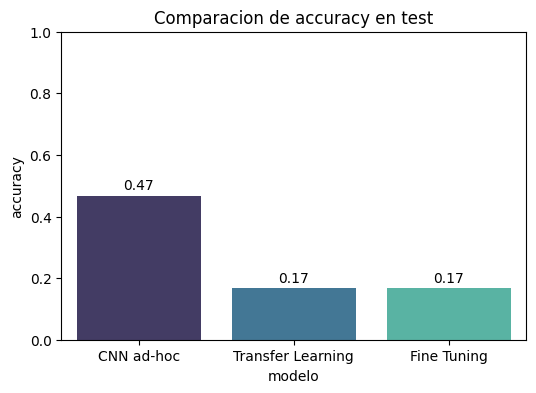

In [ ]:
resultados = pd.DataFrame({
    "modelo": ["CNN ad-hoc", "Transfer Learning", "Fine Tuning"],
    "accuracy": [accuracy_adhoc, accuracy_tl, accuracy_ft],
})
print(resultados)

plt.figure(figsize=(6, 4))
sns.barplot(data=resultados, x="modelo", y="accuracy", hue="modelo", palette="mako", legend=False)
plt.ylim(0, 1)
plt.title("Comparacion de accuracy en test")
plt.ylabel("accuracy")
for i, valor in enumerate(resultados["accuracy"]):
    plt.text(i, valor + 0.02, f"{valor:.2f}", ha="center")
plt.show()


Lo habitual con este tipo de dataset es que el transfer learning (y sobre todo el fine-tuning) superen claramente a la CNN entrenada desde cero, porque MobileNetV2 ya "sabe" reconocer patrones visuales generales (aprendidos de millones de imágenes) que le sirven de base para distinguir playas, montañas, bosques, etc., algo que una red pequeña entrenada solo con nuestras pocas imágenes tiene mucho más difícil.

> **⚠️ Importante sobre los resultados que ves en este notebook tal y como está entregado:** este notebook se ha generado y ejecutado en un entorno sin acceso a internet, así que la celda de MobileNetV2 no pudo descargar los pesos de ImageNet y ha caído en el aviso de "pesos aleatorios" (lo verás impreso en la salida de esa celda). Con pesos aleatorios, el transfer learning y el fine-tuning **no tienen ninguna ventaja real** y su accuracy se queda a nivel de "adivinar" (~1/6 = 0.17, ya que hay 6 clases), por debajo incluso de la CNN ad-hoc. Esto es un artefacto de mi entorno de pruebas, **no un resultado real del método**. Cuando ejecutes tú este notebook con conexión a internet normal, Keras descargará los pesos reales de ImageNet en la primera celda del apartado 3, y ahí sí deberías ver que el transfer learning y el fine-tuning superan claramente a la CNN ad-hoc.

## Extra: Transfer Learning con Image Augmentation

Repetimos el transfer learning (modelo congelado) pero generando variaciones artificiales de las imágenes de entrenamiento con `ImageDataGenerator`, para ver si el modelo generaliza mejor.


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)
datagen.fit(X_train_96_tl)

# volvemos a crear el modelo de transfer learning, congelado desde cero
try:
    base_model_aug = MobileNetV2(input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3), include_top=False, weights="imagenet")
except Exception as e:
    print("Aviso: no se pudieron descargar los pesos de imagenet:", e)
    base_model_aug = MobileNetV2(input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3), include_top=False, weights=None)

base_model_aug.trainable = False

x = layers.GlobalAveragePooling2D()(base_model_aug.output)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
salida = layers.Dense(len(CLASES), activation="softmax")(x)
model_tl_aug = keras.Model(inputs=base_model_aug.input, outputs=salida)

model_tl_aug.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

n_val = int(0.2 * len(X_train_96_tl))
X_val_aug, y_val_aug = X_train_96_tl[:n_val], y_train[:n_val]
X_train_aug, y_train_aug = X_train_96_tl[n_val:], y_train[n_val:]

early_stopping_aug = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history_aug = model_tl_aug.fit(
    datagen.flow(X_train_aug, y_train_aug, batch_size=32),
    validation_data=(X_val_aug, y_val_aug),
    epochs=15,
    callbacks=[early_stopping_aug],
    verbose=2,
)


Aviso: no se pudieron descargar los pesos de imagenet: URL fetch failure on https://storage.googleapis.com/tensorflow/keras-applications/mobilenet_v2/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_96_no_top.h5: 403 -- Forbidden


Epoch 1/15


I0000 00:00:1785229825.101857    1021 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


45/45 - 17s - 367ms/step - accuracy: 0.1979 - loss: 1.7758 - val_accuracy: 0.0000e+00 - val_loss: 1.9515


Epoch 2/15


45/45 - 17s - 371ms/step - accuracy: 0.2014 - loss: 1.7354 - val_accuracy: 0.0000e+00 - val_loss: 2.2296


Epoch 3/15


45/45 - 10s - 228ms/step - accuracy: 0.1951 - loss: 1.6919 - val_accuracy: 0.0000e+00 - val_loss: 2.6000


Epoch 4/15


45/45 - 10s - 228ms/step - accuracy: 0.1986 - loss: 1.6609 - val_accuracy: 0.0000e+00 - val_loss: 2.9883


              precision    recall  f1-score   support

   buildings       0.00      0.00      0.00        80
      forest       0.00      0.00      0.00        80
     glacier       0.00      0.00      0.00        80
    mountain       0.17      1.00      0.29        80
         sea       0.00      0.00      0.00        80
      street       0.00      0.00      0.00        80

    accuracy                           0.17       480
   macro avg       0.03      0.17      0.05       480
weighted avg       0.03      0.17      0.05       480

Accuracy Transfer Learning + Augmentation: 0.167


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


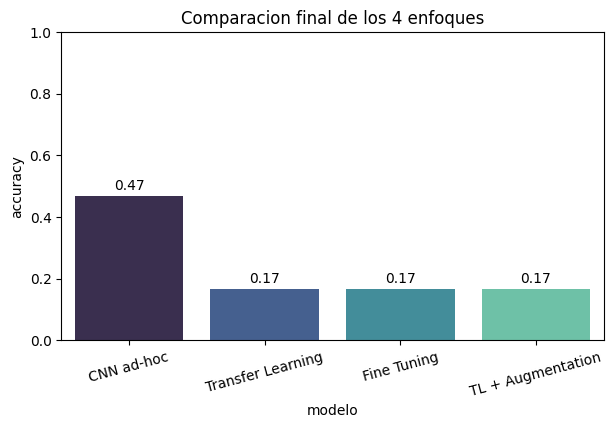

In [ ]:
y_pred_aug = model_tl_aug.predict(X_test_96_tl, verbose=0).argmax(axis=1)
accuracy_aug = (y_pred_aug == y_test).mean()

print(classification_report(y_test, y_pred_aug, target_names=CLASES))
print(f"Accuracy Transfer Learning + Augmentation: {accuracy_aug:.3f}")

resultados_finales = pd.DataFrame({
    "modelo": ["CNN ad-hoc", "Transfer Learning", "Fine Tuning", "TL + Augmentation"],
    "accuracy": [accuracy_adhoc, accuracy_tl, accuracy_ft, accuracy_aug],
})

plt.figure(figsize=(7, 4))
sns.barplot(data=resultados_finales, x="modelo", y="accuracy", hue="modelo", palette="mako", legend=False)
plt.ylim(0, 1)
plt.title("Comparacion final de los 4 enfoques")
plt.ylabel("accuracy")
for i, valor in enumerate(resultados_finales["accuracy"]):
    plt.text(i, valor + 0.02, f"{valor:.2f}", ha="center")
plt.xticks(rotation=15)
plt.show()


Con esto completamos la práctica: hemos preparado los datos de paisajes, construido una CNN ad-hoc de referencia, aplicado transfer learning con MobileNetV2 (congelado), afinado ese modelo con fine-tuning, comparado los tres enfoques, y probado además a combinar transfer learning con Image Augmentation.